# JAX for high-performance GPU computing

This notebook is a short tutorial introducing the core ideas behind JAX and the main reasons it is useful for numerical computing.

By the end, you should have a practical understanding of:

- how JAX handles arrays
- how random numbers are generated in JAX
- how GPU acceleration changes performance
- how `jit`, `grad`, and `vmap` fit into the workflow

JAX combines three key ideas that make it especially powerful for scientific and machine-learning workloads:

- just-in-time compilation (`jit`)
- automatic differentiation (`grad`)
- accelerated linear algebra (`xla`)

In [25]:
import jax.numpy as jnp
import numpy as np
from jax import grad, jit, vmap
from jax import random
import matplotlib.pyplot as plt

## 1. Arrays and JAX data structures

JAX arrays behave a lot like NumPy arrays. They support the same basic operations such as indexing, slicing, reshaping, arithmetic, and broadcasting.

The main difference is that JAX arrays are designed to work naturally with compiled numerical code and accelerator hardware. In other words, they are not just a cosmetic reimplementation of NumPy; they are built for high-performance computation.

Let’s start by comparing a standard NumPy array with a JAX array to see the similarities and the practical differences.

In [26]:
np.zeros((3, 3))

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [27]:
jnp.zeros((3, 3))

Array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)

## 2. Random numbers in JAX

Random number generation in JAX is slightly different from NumPy because JAX uses explicit pseudo-random keys rather than a single shared global random state.

This design makes random generation more reproducible and easier to reason about in compiled, batched, or distributed code. Instead of mutating a global generator, we create a key and pass it explicitly to the random function we want to use.

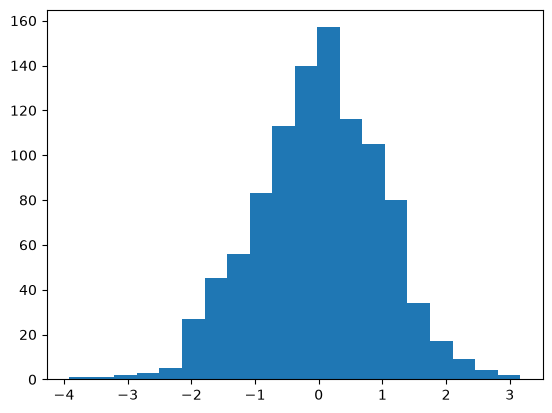

In [28]:
key = random.PRNGKey(0)
x = random.normal(key, (1000,))
plt.hist(x, bins=20)
plt.show()

## 3. Performance: matrix multiplication on the GPU

One of the main reasons to use JAX is its ability to run large numerical operations efficiently, especially when the computation is offloaded to a GPU or other accelerator.

A dense matrix multiplication is a good example because it is both common and computationally heavy. We can compare the performance of JAX against standard NumPy to see the practical difference.

In [29]:
size = 3000
x = random.normal(key, (size,size), dtype = jnp.float32)
%timeit jnp.dot(x, x.T).block_until_ready()  # runs on the GPU

79.4 ms ± 1.56 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [30]:
y = np.random.rand(size, size)
%timeit np.dot(y, y.T)

702 ms ± 151 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


This comparison is useful because JAX NumPy functions can also accept ordinary NumPy arrays. However, when that happens, JAX usually has to move the data onto the device before the computation can run.

That cost of transfer can dominate the total runtime for small or medium-sized arrays. In practice, it is much more efficient to create or convert arrays in JAX format before running large numerical operations.

In [31]:
from jax._src.api import block_until_ready

In [32]:
x = np.random.normal(size = (size,size)).astype(np.float32)
%timeit jnp.dot(x, x.T).block_until_ready()

86.3 ms ± 991 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


This is slower because every call must copy data from the CPU to the GPU before the computation begins. A simple way to reduce that overhead is to move the array to the device once using `device_put()`.

The result still behaves like a JAX array, but it remains on the accelerator until it is explicitly needed on the host for printing, plotting, saving, or branching logic.

In [33]:
from jax import device_put

In [34]:
x = np.random.normal(size = (size,size)).astype(np.float32)
x = device_put(x)
%timeit jnp.dot(x, x.T).block_until_ready()

87.1 ms ± 2.77 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## 4. Core JAX transformations

JAX is much more than a GPU-backed version of NumPy. It includes a small set of core transformations that are especially useful in numerical computing.

These are the three most important ones to understand first:

- `jit()`: compiles a function so it can run efficiently
- `grad()`: automatically computes derivatives
- `vmap()`: applies a function across array batches or dimensions

These tools often work together in real workflows. For example, you might compile a function with `jit`, differentiate it with `grad`, and batch operations with `vmap` to process many inputs at once. We’ll explore each of these in turn.

# `jit()`

